# Homework 3

This notebook uses logistic regression to classify diabetes outcomes and cancer diagnoses. All models use an 80/20 training and testing split.

In [1]:
# Import the libraries used in this homework.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Load the diabetes and cancer datasets from Google Drive.
diabetes = pd.read_csv('/content/drive/MyDrive/Dataset/diabetes.csv')
cancer = pd.read_csv('/content/drive/MyDrive/Dataset/Cancer.csv')

print('Diabetes shape:', diabetes.shape)
print('Cancer shape:', cancer.shape)

Diabetes shape: (768, 9)
Cancer shape: (569, 33)


## Problem 1 Diabetes Classification

In [3]:
# Replace impossible zero measurements with missing values.
missing_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
diabetes[missing_cols] = diabetes[missing_cols].replace(0, np.nan)

print(diabetes[missing_cols].isnull().sum())

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [4]:
# Separate the inputs and target, then keep the class ratio in the 80/20 split.
from sklearn.model_selection import train_test_split
X = diabetes.drop('Outcome', axis=1)
Y = diabetes['Outcome']
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42, stratify=Y)

X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((614, 8), (154, 8), (614,), (154,))

In [5]:
# Fill missing values with training medians and standardize the inputs.
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
# Train logistic regression one epoch at a time and save loss and accuracy.
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss, accuracy_score
from sklearn.utils import shuffle

classifier = SGDClassifier(loss='log_loss', penalty=None, learning_rate='constant',
                           eta0=0.01, random_state=42)
iterations, classes = 100, np.array([0, 1])
training_losses, testing_losses = [], []
training_accuracies, testing_accuracies = [], []
Y_train_array, Y_test_array = np.asarray(Y_train), np.asarray(Y_test)

for iteration in range(iterations):
    X_epoch, Y_epoch = shuffle(X_train, Y_train_array, random_state=iteration)
    classifier.partial_fit(X_epoch, Y_epoch, classes=classes)
    train_prob, test_prob = classifier.predict_proba(X_train), classifier.predict_proba(X_test)
    train_pred, test_pred = classifier.predict(X_train), classifier.predict(X_test)
    training_losses.append(log_loss(Y_train_array, train_prob, labels=classes))
    testing_losses.append(log_loss(Y_test_array, test_prob, labels=classes))
    training_accuracies.append(accuracy_score(Y_train_array, train_pred))
    testing_accuracies.append(accuracy_score(Y_test_array, test_pred))

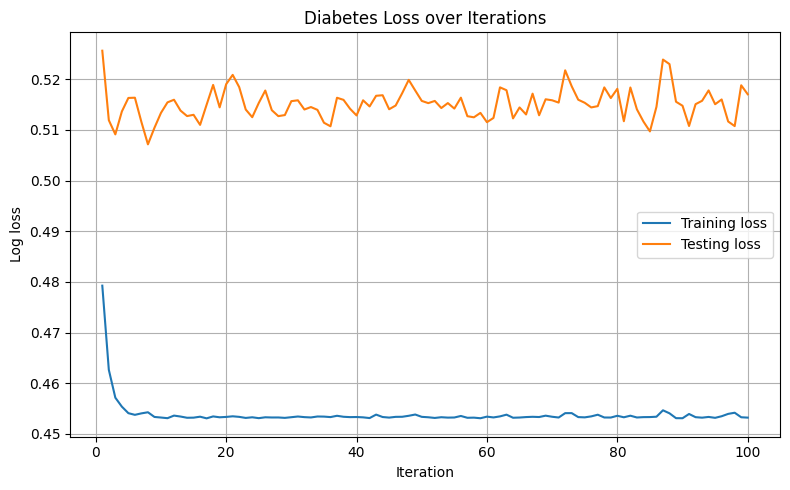

In [7]:
# Plot training and testing loss.
plt.figure(figsize=(8, 5))
plt.plot(range(1, iterations + 1), training_losses, label='Training loss')
plt.plot(range(1, iterations + 1), testing_losses, label='Testing loss')
plt.xlabel('Iteration'); plt.ylabel('Log loss'); plt.title('Diabetes Loss over Iterations')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

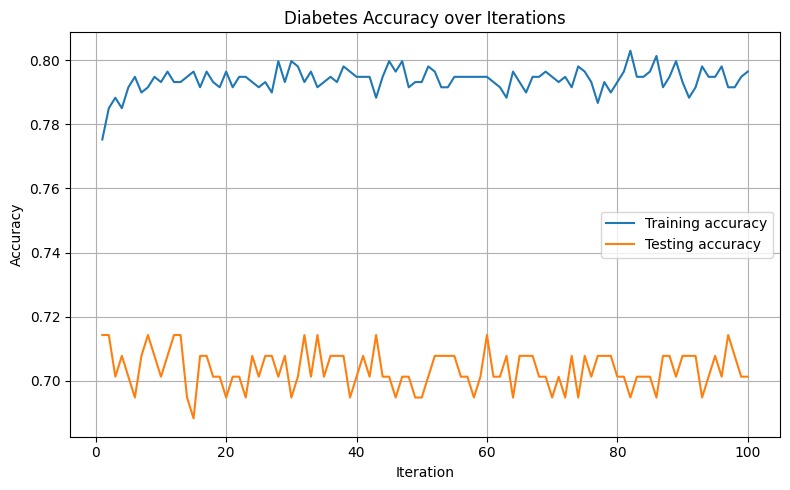

In [8]:
# Plot training and testing accuracy.
plt.figure(figsize=(8, 5))
plt.plot(range(1, iterations + 1), training_accuracies, label='Training accuracy')
plt.plot(range(1, iterations + 1), testing_accuracies, label='Testing accuracy')
plt.xlabel('Iteration'); plt.ylabel('Accuracy'); plt.title('Diabetes Accuracy over Iterations')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

In [9]:
# Calculate the final diabetes classification results.
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
Y_pred = classifier.predict(X_test)
accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')
print('\nClassification Report:')
print(classification_report(Y_test, Y_pred, target_names=['Negative', 'Positive']))

Accuracy:  0.7013
Precision: 0.5870
Recall:    0.5000
F1 Score:  0.5400

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.81      0.78       100
    Positive       0.59      0.50      0.54        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154



[[81 19]
 [27 27]]


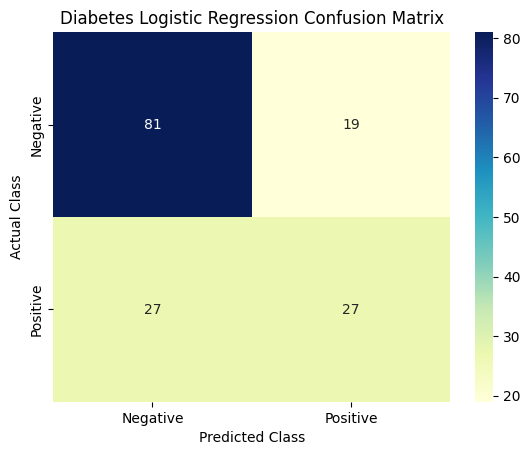

In [10]:
# Plot the diabetes confusion matrix.
from sklearn.metrics import confusion_matrix
diabetes_cm = confusion_matrix(Y_test, Y_pred)
print(diabetes_cm)
sns.heatmap(diabetes_cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Class'); plt.ylabel('Actual Class')
plt.title('Diabetes Logistic Regression Confusion Matrix'); plt.show()

## Problem 2 Cancer Classification

Part 1 uses all 30 features without a penalty. Part 2 repeats the model with an L2 penalty.

In [11]:
# Remove the patient ID and empty column, then encode malignant as 1.
X_cancer = cancer.drop(columns=['id', 'diagnosis', 'Unnamed: 32'])
Y_cancer = cancer['diagnosis'].map({'M': 1, 'B': 0})

print('Input shape:', X_cancer.shape)
print('Target shape:', Y_cancer.shape)
print(Y_cancer.value_counts())

Input shape: (569, 30)
Target shape: (569,)
diagnosis
0    357
1    212
Name: count, dtype: int64


In [12]:
# Split the cancer data and standardize all 30 inputs.
X_cancer_train, X_cancer_test, Y_cancer_train, Y_cancer_test = train_test_split(
    X_cancer, Y_cancer, test_size=0.20, random_state=42, stratify=Y_cancer)
cancer_scaler = StandardScaler()
X_cancer_train = cancer_scaler.fit_transform(X_cancer_train)
X_cancer_test = cancer_scaler.transform(X_cancer_test)

X_cancer_train.shape, X_cancer_test.shape

((455, 30), (114, 30))

### Part 1 Model Without Weight Penalty

In [13]:
# Train the cancer model without a weight penalty.
cancer_classifier = SGDClassifier(loss='log_loss', penalty=None, learning_rate='constant',
                                  eta0=0.01, random_state=42)
cancer_iterations, cancer_classes = 100, np.array([0, 1])
cancer_training_losses, cancer_testing_losses = [], []
cancer_training_accuracies, cancer_testing_accuracies = [], []
Y_cancer_train_array = np.asarray(Y_cancer_train)
Y_cancer_test_array = np.asarray(Y_cancer_test)

for iteration in range(cancer_iterations):
    X_epoch, Y_epoch = shuffle(X_cancer_train, Y_cancer_train_array, random_state=iteration)
    cancer_classifier.partial_fit(X_epoch, Y_epoch, classes=cancer_classes)
    train_prob = cancer_classifier.predict_proba(X_cancer_train)
    test_prob = cancer_classifier.predict_proba(X_cancer_test)
    train_pred = cancer_classifier.predict(X_cancer_train)
    test_pred = cancer_classifier.predict(X_cancer_test)
    cancer_training_losses.append(log_loss(Y_cancer_train_array, train_prob, labels=cancer_classes))
    cancer_testing_losses.append(log_loss(Y_cancer_test_array, test_prob, labels=cancer_classes))
    cancer_training_accuracies.append(accuracy_score(Y_cancer_train_array, train_pred))
    cancer_testing_accuracies.append(accuracy_score(Y_cancer_test_array, test_pred))

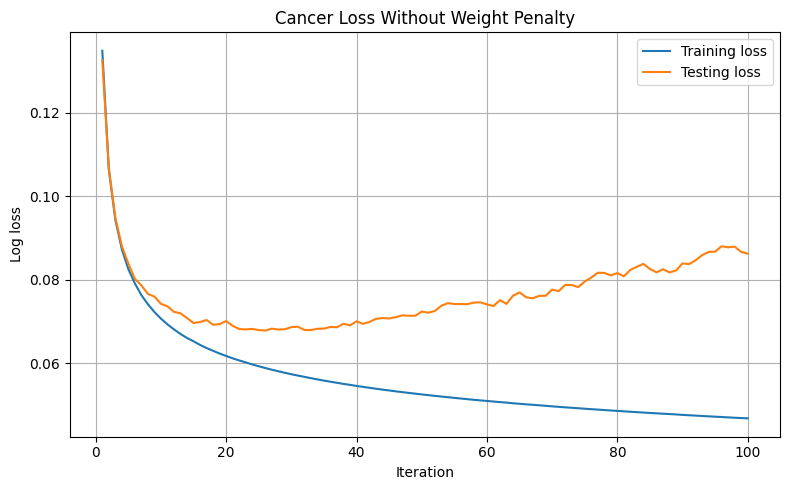

In [14]:
# Plot cancer loss without a penalty.
plt.figure(figsize=(8, 5))
plt.plot(range(1, 101), cancer_training_losses, label='Training loss')
plt.plot(range(1, 101), cancer_testing_losses, label='Testing loss')
plt.xlabel('Iteration'); plt.ylabel('Log loss')
plt.title('Cancer Loss Without Weight Penalty')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

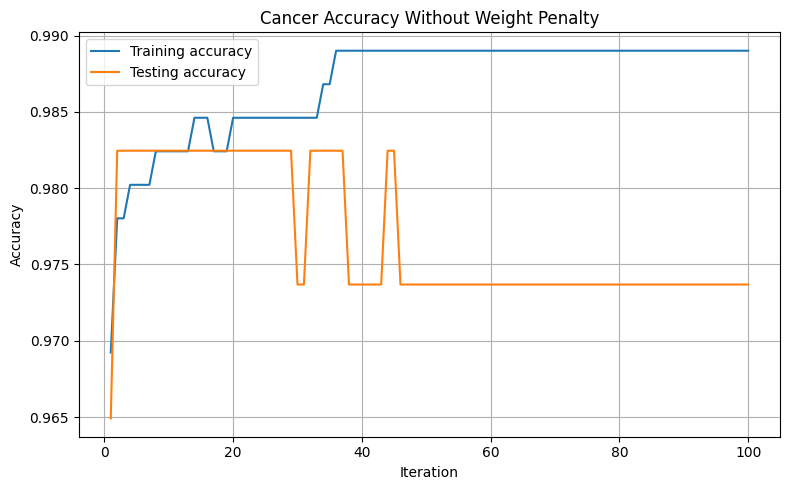

In [15]:
# Plot cancer accuracy without a penalty.
plt.figure(figsize=(8, 5))
plt.plot(range(1, 101), cancer_training_accuracies, label='Training accuracy')
plt.plot(range(1, 101), cancer_testing_accuracies, label='Testing accuracy')
plt.xlabel('Iteration'); plt.ylabel('Accuracy')
plt.title('Cancer Accuracy Without Weight Penalty')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

In [16]:
# Report the cancer results without a penalty.
Y_cancer_pred = cancer_classifier.predict(X_cancer_test)
cancer_accuracy = accuracy_score(Y_cancer_test, Y_cancer_pred)
cancer_precision = precision_score(Y_cancer_test, Y_cancer_pred)
cancer_recall = recall_score(Y_cancer_test, Y_cancer_pred)
cancer_f1 = f1_score(Y_cancer_test, Y_cancer_pred)

print(f'Accuracy:  {cancer_accuracy:.4f}')
print(f'Precision: {cancer_precision:.4f}')
print(f'Recall:    {cancer_recall:.4f}')
print(f'F1 Score:  {cancer_f1:.4f}')
print('\nClassification Report:')
print(classification_report(Y_cancer_test, Y_cancer_pred,
                            target_names=['Benign', 'Malignant']))

Accuracy:  0.9737
Precision: 0.9756
Recall:    0.9524
F1 Score:  0.9639

Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        72
   Malignant       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



[[71  1]
 [ 2 40]]


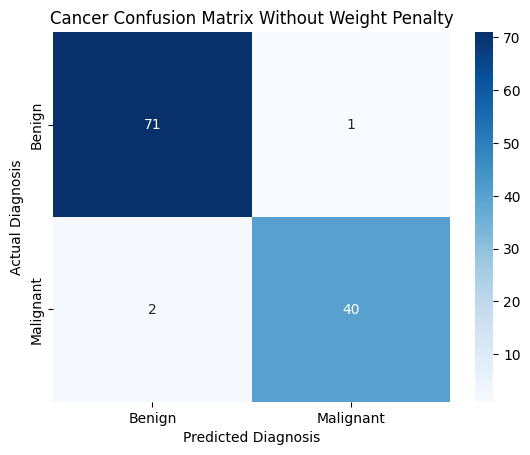

In [17]:
# Plot the cancer confusion matrix without a penalty.
cancer_cm = confusion_matrix(Y_cancer_test, Y_cancer_pred)
print(cancer_cm)
sns.heatmap(cancer_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted Diagnosis'); plt.ylabel('Actual Diagnosis')
plt.title('Cancer Confusion Matrix Without Weight Penalty'); plt.show()

### Part 2 Model With L2 Weight Penalty

In [18]:
# Repeat training with an L2 weight penalty.
cancer_classifier_l2 = SGDClassifier(loss='log_loss', penalty='l2', alpha=0.01,
                                     learning_rate='constant', eta0=0.01, random_state=42)
cancer_l2_training_losses, cancer_l2_testing_losses = [], []
cancer_l2_training_accuracies, cancer_l2_testing_accuracies = [], []

for iteration in range(cancer_iterations):
    X_epoch, Y_epoch = shuffle(X_cancer_train, Y_cancer_train_array, random_state=iteration)
    cancer_classifier_l2.partial_fit(X_epoch, Y_epoch, classes=cancer_classes)
    train_prob = cancer_classifier_l2.predict_proba(X_cancer_train)
    test_prob = cancer_classifier_l2.predict_proba(X_cancer_test)
    train_pred = cancer_classifier_l2.predict(X_cancer_train)
    test_pred = cancer_classifier_l2.predict(X_cancer_test)
    cancer_l2_training_losses.append(log_loss(Y_cancer_train_array, train_prob, labels=cancer_classes))
    cancer_l2_testing_losses.append(log_loss(Y_cancer_test_array, test_prob, labels=cancer_classes))
    cancer_l2_training_accuracies.append(accuracy_score(Y_cancer_train_array, train_pred))
    cancer_l2_testing_accuracies.append(accuracy_score(Y_cancer_test_array, test_pred))

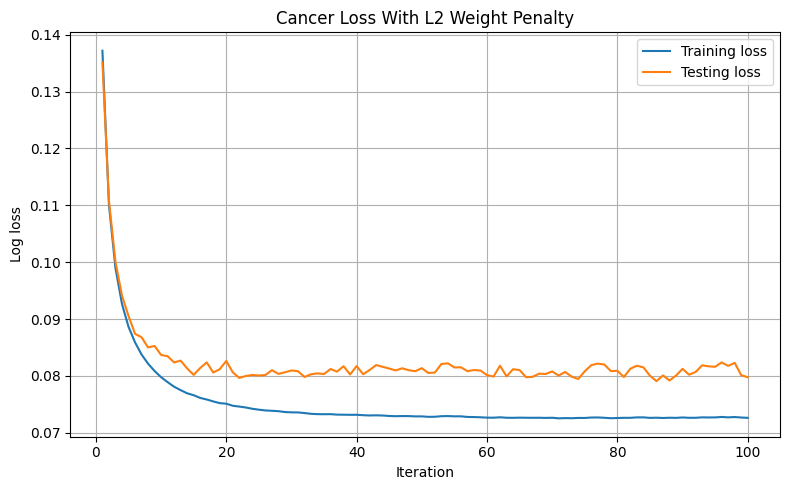

In [19]:
# Plot cancer loss with the L2 penalty.
plt.figure(figsize=(8, 5))
plt.plot(range(1, 101), cancer_l2_training_losses, label='Training loss')
plt.plot(range(1, 101), cancer_l2_testing_losses, label='Testing loss')
plt.xlabel('Iteration'); plt.ylabel('Log loss')
plt.title('Cancer Loss With L2 Weight Penalty')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

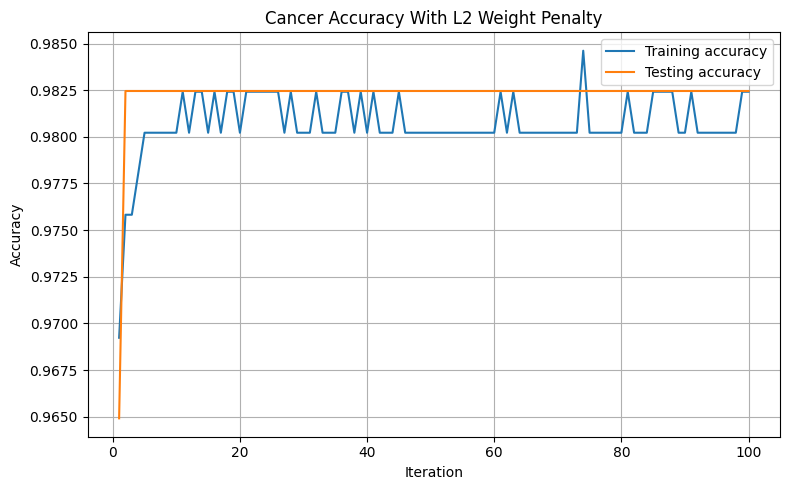

In [20]:
# Plot cancer accuracy with the L2 penalty.
plt.figure(figsize=(8, 5))
plt.plot(range(1, 101), cancer_l2_training_accuracies, label='Training accuracy')
plt.plot(range(1, 101), cancer_l2_testing_accuracies, label='Testing accuracy')
plt.xlabel('Iteration'); plt.ylabel('Accuracy')
plt.title('Cancer Accuracy With L2 Weight Penalty')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

In [21]:
# Report the cancer results with the L2 penalty.
Y_cancer_pred_l2 = cancer_classifier_l2.predict(X_cancer_test)
cancer_l2_accuracy = accuracy_score(Y_cancer_test, Y_cancer_pred_l2)
cancer_l2_precision = precision_score(Y_cancer_test, Y_cancer_pred_l2)
cancer_l2_recall = recall_score(Y_cancer_test, Y_cancer_pred_l2)
cancer_l2_f1 = f1_score(Y_cancer_test, Y_cancer_pred_l2)

print(f'Accuracy:  {cancer_l2_accuracy:.4f}')
print(f'Precision: {cancer_l2_precision:.4f}')
print(f'Recall:    {cancer_l2_recall:.4f}')
print(f'F1 Score:  {cancer_l2_f1:.4f}')
print('\nClassification Report:')
print(classification_report(Y_cancer_test, Y_cancer_pred_l2,
                            target_names=['Benign', 'Malignant']))

Accuracy:  0.9825
Precision: 1.0000
Recall:    0.9524
F1 Score:  0.9756

Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



[[72  0]
 [ 2 40]]


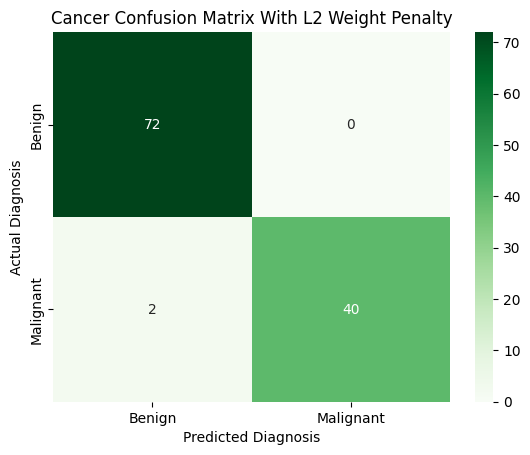

In [22]:
# Plot the cancer confusion matrix with the L2 penalty.
cancer_cm_l2 = confusion_matrix(Y_cancer_test, Y_cancer_pred_l2)
print(cancer_cm_l2)
sns.heatmap(cancer_cm_l2, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted Diagnosis'); plt.ylabel('Actual Diagnosis')
plt.title('Cancer Confusion Matrix With L2 Weight Penalty'); plt.show()

In [23]:
# Compare the final cancer models.
comparison = pd.DataFrame({
    'Model': ['Without penalty', 'With L2 penalty'],
    'Accuracy': [cancer_accuracy, cancer_l2_accuracy],
    'Precision': [cancer_precision, cancer_l2_precision],
    'Recall': [cancer_recall, cancer_l2_recall],
    'F1 Score': [cancer_f1, cancer_l2_f1]
})
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Without penalty,0.973684,0.97561,0.952381,0.963855
1,With L2 penalty,0.982456,1.00000,0.952381,0.975610
